# در این مثال داده های زمانی تخلیه باتری های یون لیتیوم از فایل اصلی استخراج شده و یک مدل طول عمر مفید و وضعیت سلامت باتری آموزش داده می شود. 

### فراخوانی کتابخانه های مورد نیاز

!pip install pytorch==2.4.1 datetime

In [1]:
import datetime
import numpy as np
import pandas as pd
from scipy.io import loadmat
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn import metrics
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import random as rnd

### تبدیل داده به سری زمانی، هر سری حاوی 10 نمونه و سری ها با یکدیگر تداخل دارند

In [2]:
def generate_sequences(data, window_size):
    X, y_capacity, y_RUL, y_SOH = [], [], [], []
    cyclic_RUL_x, cyclic_RUL_y = [], []

    cycles = data['cycle'].unique()
    initial_capacity = data.iloc[0]['capacity']

    # Normalize all 'capacity' values by the first row's 'capacity' value
    data['SOH'] = data['capacity'] / initial_capacity

    # dividing the data of each cycle into sequences
    for cycle in cycles:
        cycle_data = data[data['cycle'] == cycle]
        cycle_observations = []
        num_rows = len(cycle_data)

        if num_rows >= window_size:
            for start in range(num_rows - window_size + 1):
                end = start + window_size

                features = cycle_data.iloc[start:end].drop(['cycle', 'capacity', 'RUL', 'SOH'], axis=1).values # حذف ستونهای 'cycle', 'capacity', 'RUL', 'SOH'
                target_capacity = cycle_data.iloc[end-1, cycle_data.columns.get_loc('capacity')] # Capacity هدف
                target_SOH = cycle_data.iloc[end-1, cycle_data.columns.get_loc('SOH')] # SOH هدف
                target_RUL = cycle_data.iloc[end-1, cycle_data.columns.get_loc('RUL')] # RUL هدف
                cycle_observations.append(features)
                X.append(features)
                y_capacity.append(target_capacity)
                y_SOH.append(target_SOH)
                y_RUL.append(target_RUL)

            cyclic_RUL_x.append(y_capacity[-1])
            cyclic_RUL_y.append(y_RUL[-1])

    return np.array(X), np.array(y_capacity), np.array(y_SOH), np.array(y_RUL), np.array(cyclic_RUL_x), np.array(cyclic_RUL_y)

### فراخوانی داده ها و ایجاد سری زمانی

In [3]:
file_path_0005 = 'B0005_discharge.csv'
file_path_0006 = 'B0006_discharge.csv'
file_path_0007 = 'B0007_discharge.csv'
file_path_0018 = 'B0018_discharge.csv'

# فراخوانی داده
data_0005 = pd.read_csv(file_path_0005)
data_0006 = pd.read_csv(file_path_0006)
data_0007 = pd.read_csv(file_path_0007)
data_0018 = pd.read_csv(file_path_0018)

# ایجاد سری زمانی
X_0005, y_capacit_0005, y_SOH_0005, y_RUL_0005, cyclic_RUL_x_0005, cyclic_RUL_y_0005  = generate_sequences(data_0005, 10)
X_0006, y_capacit_0006, y_SOH_0006,  y_RUL_0006, cyclic_RUL_x_0006, cyclic_RUL_y_0006 = generate_sequences(data_0006, 10)
X_0007, y_capacit_0007, y_SOH_0007,  y_RUL_0007, cyclic_RUL_x_0007, cyclic_RUL_y_0007 = generate_sequences(data_0007, 10)
X_0018, y_capacit_0018, y_SOH_0018,  y_RUL_0018, cyclic_RUL_x_0018, cyclic_RUL_y_0018 = generate_sequences(data_0018, 10)
print(X_0018.shape)

(33678, 10, 7)


In [4]:
# تجمیع داده ها
X = np.concatenate((X_0005, X_0006, X_0007, X_0018), axis=0)
y_capacity = np.concatenate((y_capacit_0005, y_capacit_0006, y_capacit_0007, y_capacit_0018), axis=0)
y_SOH = np.concatenate((y_SOH_0005, y_SOH_0006, y_SOH_0007, y_SOH_0018), axis=0)
y_RUL = np.concatenate((y_RUL_0005, y_RUL_0006, y_RUL_0007, y_RUL_0018), axis=0)
cyclic_RUL_x = np.concatenate((cyclic_RUL_x_0005, cyclic_RUL_x_0006, cyclic_RUL_x_0007, cyclic_RUL_x_0018), axis=0)
cyclic_RUL_y = np.concatenate((cyclic_RUL_y_0005, cyclic_RUL_y_0006, cyclic_RUL_y_0007, cyclic_RUL_y_0018), axis=0)

## پیش بینی SOH/Capacity

## پیش بینی ظرفیت خام

### تقسیم داده به آموزش، تست و ارزیابی برای بررسی هدف (ظرفیت)

In [5]:
X_capacity_train, X_capacity_testval, y_capacity_train, y_capacity_testval = train_test_split(
                                                                        X, y_capacity, test_size=0.2, random_state=42)

X_capacity_test, X_capacity_validation, y_capacity_test, y_capacity_validation = train_test_split(
                                                        X_capacity_testval, y_capacity_testval, test_size=0.5, random_state=42)
X_capacity_train.shape

(143997, 10, 7)

### تعریف آرایش مدل با Pytorch
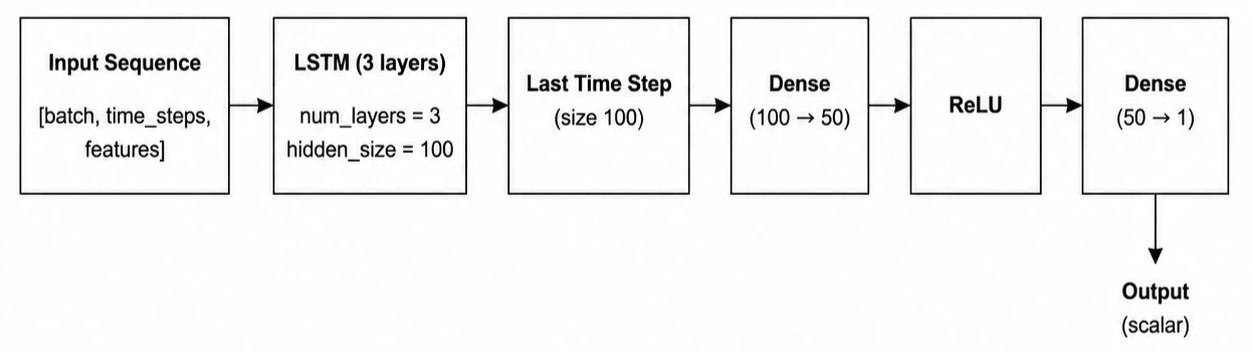

In [6]:
time_steps = X_capacity_train.shape[1]
features = X_capacity_train.shape[2]

class BatteryLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=100, dense_size=50, num_layers=3):
        super(BatteryLSTM,self).__init__()
        
        self.lstm = nn.LSTM(
        input_size=input_size,
        hidden_size=hidden_size,
        num_layers=num_layers,
        batch_first=True    
        )
        
        self.fc1 = nn.Linear(hidden_size, dense_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(dense_size, 1) # خروجی 1 هدف

    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x) # x:[batch, time_steps, features]
        last_out = out[:, -1, :]
        x = self.fc1(last_out)
        x = self.relu(x)
        x = self.fc2(x)
        return x

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = BatteryLSTM(input_size=features, hidden_size=100, dense_size=50, num_layers=3).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

### تبدیل داده به تانسور

In [7]:
X_train = torch.tensor(X_capacity_train, dtype=torch.float32)
y_train = torch.tensor(y_capacity_train, dtype=torch.float32)

X_val = torch.tensor(X_capacity_validation, dtype=torch.float32)
y_val = torch.tensor(y_capacity_validation, dtype=torch.float32)

batch_size = 16
train_dataset = TensorDataset(X_train, y_train)
val_dataset   = TensorDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

### آموزش

In [ ]:
num_epochs = 20
for epoch in range(num_epochs):
    
    # آموزش
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device).view(-1,1)
        
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        
        running_loss +=loss.item() * X_batch.size(0)
    
    epoch_train_loss = running_loss / len(train_loader.dataset)
    
    # ارزیابی
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
         for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device).view(-1,1)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item() * X_batch.size(0)
    
    epoch_val_loss = val_loss / len(val_loader.dataset)
    
    print(f'Epoch {epoch+1}/{num_epochs} -'
         f"train_loss: {epoch_train_loss:.4f} val_loss: {epoch_val_loss:.4f}")

### ذخیره مدل و فراخوانی آن

In [9]:
torch.save(model.state_dict(), "Raw_Capacity_LSTM.pt")

In [8]:
model = BatteryLSTM(input_size=features, hidden_size=100, dense_size=50, num_layers=3)
model.load_state_dict(torch.load('Raw_Capacity_LSTM.pt', map_location=device, weights_only=True))
model.to(device)
model.eval()

BatteryLSTM(
  (lstm): LSTM(7, 100, num_layers=3, batch_first=True)
  (fc1): Linear(in_features=100, out_features=50, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=50, out_features=1, bias=True)
)

### بررسی خطای مدل با داده های تست

Mean Squared Error: 0.010937556427114244
Mean Absolute Error: 0.07897588025329198
Root Mean Squared Error: 0.10458277308961665


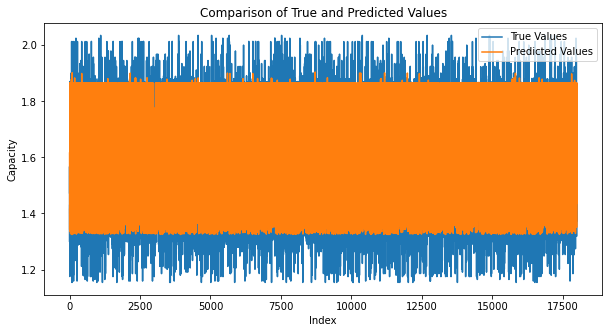

In [11]:
X_test = torch.tensor(X_capacity_test, dtype=torch.float32)
y_true = np.array(y_capacity_test).reshape(-1)

model.eval()
with torch.no_grad():
    y_pred = model(X_test).detach().cpu().numpy().reshape(-1)

mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mse)

print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)

plt.figure(figsize=(10, 5))

plt.plot(y_true, label='True Values')

plt.plot(y_pred, label='Predicted Values')

plt.title('Comparison of True and Predicted Values')
plt.xlabel('Index')
plt.ylabel('Capacity')
plt.legend()
plt.show()

## پیش بینی وضعیت سلامت باتری SOH
### ظرفیت موجود تقسیم بر ظرفیت اولیه 

### تقسیم داده به آموزش، تست و ارزیابی برای بررسی هدف (وضعیت سلامت باتری)

In [9]:
X_SOH_train, X_SOH_testval, y_SOH_train, y_SOH_testval = train_test_split(
    X, y_SOH, test_size=0.2, random_state=42
)

X_SOH_test, X_SOH_validation, y_SOH_test, y_SOH_validation = train_test_split(
    X_SOH_testval, y_SOH_testval, test_size=0.5, random_state=42
)

### تبدیل داده ها به تانسور

In [10]:
time_steps = X_SOH_train.shape[1]
features   = X_SOH_train.shape[2]

print(time_steps,',',features)

X_train = torch.tensor(X_SOH_train, dtype=torch.float32)
y_train = torch.tensor(y_SOH_train, dtype=torch.float32)

X_val = torch.tensor(X_SOH_validation, dtype=torch.float32)
y_val = torch.tensor(y_SOH_validation, dtype=torch.float32)

batch_size = 64

train_dataset = TensorDataset(X_train, y_train)
val_dataset   = TensorDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

10 , 7


### تعریف ساختار مدل با pytorch
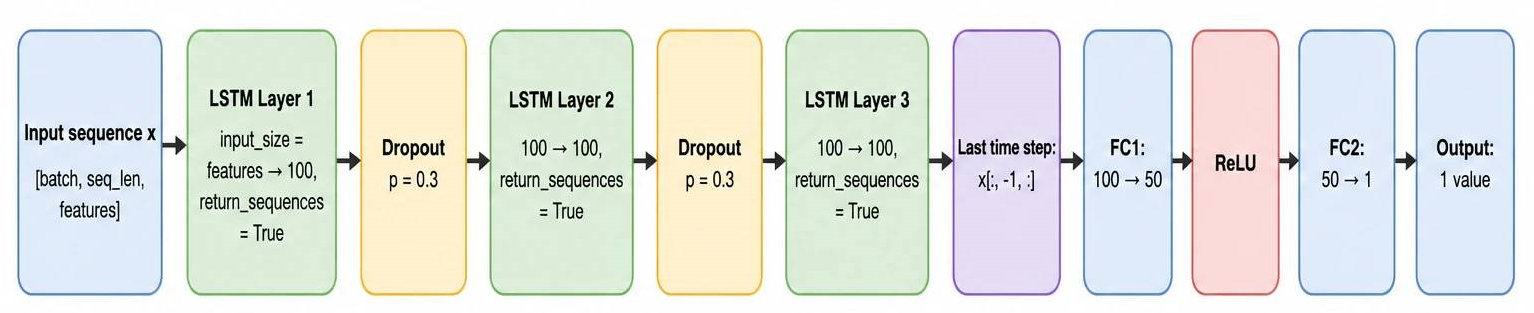

In [18]:
class SOH_LSTM(nn.Module):
    def __init__(self, input_size, hidden_size=100, dense_size=50, dropout=0.3):
        super(SOH_LSTM,self).__init__()
        
        self.lstm1 = nn.LSTM(input_size=input_size, hidden_size=hidden_size, batch_first=True)
        
        self.dropout1 = nn.Dropout(dropout)
        
        self.lstm2 = nn.LSTM(input_size=hidden_size, hidden_size=hidden_size, batch_first=True)
        
        self.dropout2 = nn.Dropout(dropout)
        
        self.lstm3 = nn.LSTM(input_size=hidden_size, hidden_size=hidden_size, batch_first=True)
        
        self.fc1 = nn.Linear(hidden_size, dense_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(dense_size, 1) # خروجی 1 عدد

    def forward(self, x):
        # LSTM1 (return_sequences=True)
        x, _ = self.lstm1(x)
        x = self.dropout1(x)
        # LSTM2 (return_sequences=True)
        x, _ = self.lstm2(x)
        x = self.dropout2(x)
        # LSTM3 (return_sequences=False)
        x, _ = self.lstm3(x)
        x = x[:, -1, :]
        # Dense layers
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

model = SOH_LSTM(input_size=features, hidden_size=100, dense_size=50, dropout=0.3).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

### آموزش

In [19]:
num_epochs = 15
for epoch in range(num_epochs):
    
    # آموزش
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device).view(-1,1)
        
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        
        running_loss +=loss.item() * X_batch.size(0)
    
    epoch_train_loss = running_loss / len(train_loader.dataset)
    
    # ارزیابی
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
         for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device).view(-1,1)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item() * X_batch.size(0)
    
    epoch_val_loss = val_loss / len(val_loader.dataset)
    
    print(f'Epoch {epoch+1}/{num_epochs} -'
         f"train_loss: {epoch_train_loss:.4f} val_loss: {epoch_val_loss:.4f}")

Epoch 1/15 -train_loss: 0.0137 val_loss: 0.0111
Epoch 2/15 -train_loss: 0.0089 val_loss: 0.0057
Epoch 3/15 -train_loss: 0.0053 val_loss: 0.0076
Epoch 4/15 -train_loss: 0.0047 val_loss: 0.0091
Epoch 5/15 -train_loss: 0.0043 val_loss: 0.0073
Epoch 6/15 -train_loss: 0.0041 val_loss: 0.0067
Epoch 7/15 -train_loss: 0.0039 val_loss: 0.0061
Epoch 8/15 -train_loss: 0.0037 val_loss: 0.0048
Epoch 9/15 -train_loss: 0.0034 val_loss: 0.0074
Epoch 10/15 -train_loss: 0.0033 val_loss: 0.0087
Epoch 11/15 -train_loss: 0.0031 val_loss: 0.0055
Epoch 12/15 -train_loss: 0.0031 val_loss: 0.0048
Epoch 13/15 -train_loss: 0.0029 val_loss: 0.0053
Epoch 14/15 -train_loss: 0.0028 val_loss: 0.0056
Epoch 15/15 -train_loss: 0.0027 val_loss: 0.0059


### ذخیره مدل و فراخوانی آن

In [20]:
torch.save(model.state_dict(), "SOH_LSTM.pt")

In [21]:
#model = SOH_LSTM(input_size=features, hidden_size=100, dense_size=50, dropout=0.3)
model.load_state_dict(torch.load('SOH_LSTM.pt', map_location=device, weights_only=True))
model.to(device)
model.eval()

SOH_LSTM(
  (lstm1): LSTM(7, 100, batch_first=True)
  (dropout1): Dropout(p=0.3, inplace=False)
  (lstm2): LSTM(100, 100, batch_first=True)
  (dropout2): Dropout(p=0.3, inplace=False)
  (lstm3): LSTM(100, 100, batch_first=True)
  (fc1): Linear(in_features=100, out_features=50, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=50, out_features=1, bias=True)
)

### بررسی خطای مدل با داده های تست

Mean Squared Error: 0.005840133358484356
Mean Absolute Error: 0.059930422873773724
Root Mean Squared Error: 0.07642076523095248


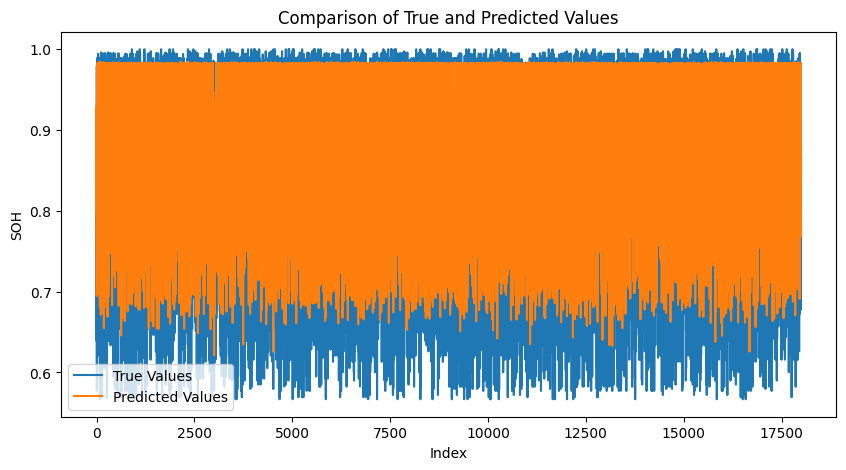

In [22]:
X_test = torch.tensor(X_SOH_test, dtype=torch.float32)
y_true = np.array(y_SOH_test)

model.eval()
with torch.no_grad():
    y_pred = model(X_test).detach().cpu().numpy().reshape(-1)

mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mse)

print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)

plt.figure(figsize=(10, 5))

plt.plot(y_true, label='True Values')

plt.plot(y_pred, label='Predicted Values')

plt.title('Comparison of True and Predicted Values')
plt.xlabel('Index')
plt.ylabel('SOH')
plt.legend()
plt.show()

# پیش بینی طول عمر مفید RUL

### تغییر شکل cyclic_RUL_x به ارایه numpy

In [23]:
cyclic_RUL_x_reshaped = np.empty((cyclic_RUL_x.shape[0], 1))
for i in range(cyclic_RUL_x.shape[0]):
    cyclic_RUL_x_reshaped[i] = np.array([cyclic_RUL_x[i]])

### استانداردسازی داده

In [24]:
scaler = MinMaxScaler()
scaled_rul = scaler.fit_transform(cyclic_RUL_y.reshape(-1, 1))

### ایجاد سری زمانی برای پیش بینی طول عمر مفید براساس SOH

In [25]:
def generate_sequences_RUL(capacity, RUL_GT, window_size):
    X, y_RUL = [], []
    for start in range(capacity.shape[0] - window_size + 1):
        end = start + window_size

        features = capacity[start:end]
        target_RUL = RUL_GT[end-1]
        X.append(features)
        y_RUL.append(target_RUL)

    return np.array(X), np.array(y_RUL)
X_for_RUL, y_RUL = generate_sequences_RUL(cyclic_RUL_x_reshaped, scaled_rul, 3)

### تقسیم داده به آموزش، تست و ارزیابی برای بررسی هدف (وضعیت سلامت باتری)

In [27]:
X_RUL_train, X_RUL_testval, y_RUL_train, y_RUL_testval = train_test_split(
    X_for_RUL, y_RUL, test_size=0.1, random_state=42
)

X_RUL_test, X_RUL_validation, y_RUL_test, y_RUL_validation = train_test_split(
    X_RUL_testval, y_RUL_testval, test_size=0.5, random_state=42
)

In [28]:
time_steps = X_RUL_train.shape[1]
features   = X_RUL_train.shape[2]

X_train = torch.tensor(X_RUL_train, dtype=torch.float32)
y_train = torch.tensor(y_RUL_train, dtype=torch.float32)

X_val = torch.tensor(X_RUL_validation, dtype=torch.float32)
y_val = torch.tensor(y_RUL_validation, dtype=torch.float32)

batch_size = 64

train_dataset = TensorDataset(X_train, y_train)
val_dataset   = TensorDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

### تعریف ساختار مدل با pytorch
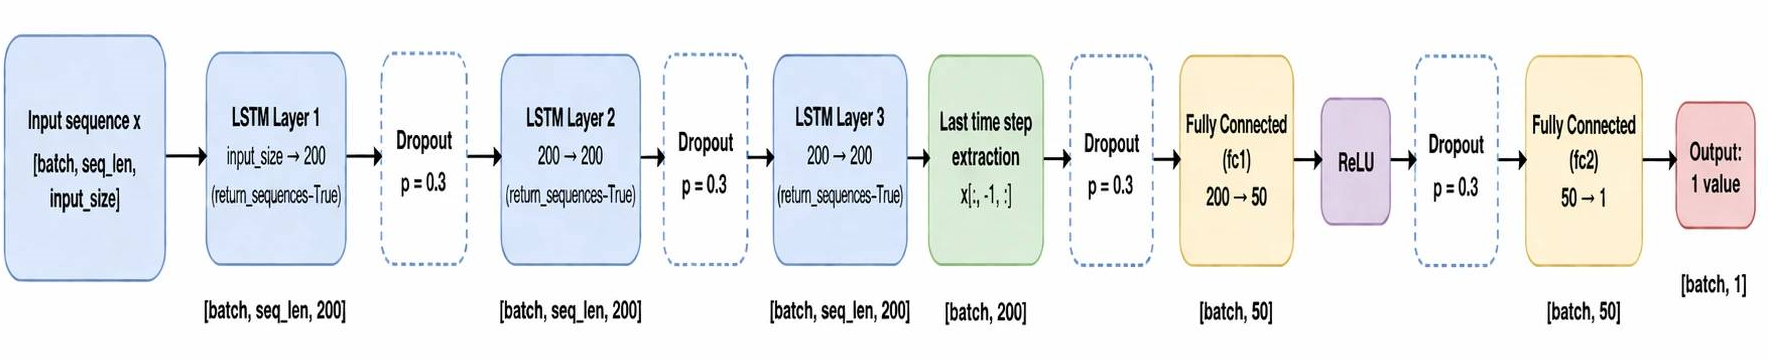

In [29]:
class RUL_LSTM(nn.Module):
    def __init__(self, input_size, hidden_size=200, dense_size=50, dropout=0.3):
        super(RUL_LSTM,self).__init__()
        
        self.lstm1 = nn.LSTM(input_size=input_size, hidden_size=hidden_size, batch_first=True)
        
        self.dropout1 = nn.Dropout(dropout)
        
        self.lstm2 = nn.LSTM(input_size=hidden_size, hidden_size=hidden_size, batch_first=True)
        
        self.dropout2 = nn.Dropout(dropout)
        
        self.lstm3 = nn.LSTM(input_size=hidden_size, hidden_size=hidden_size, batch_first=True)
        
        self.dropout3 = nn.Dropout(dropout)
        
        self.fc1 = nn.Linear(hidden_size, dense_size)
        self.relu = nn.ReLU()
        self.dropout4 = nn.Dropout(dropout)
        self.fc2 = nn.Linear(dense_size, 1) # خروجی 1 عدد

    def forward(self, x):
        # LSTM1 (return_sequences=True)
        x, _ = self.lstm1(x)
        x = self.dropout1(x)
        # LSTM2 (return_sequences=True)
        x, _ = self.lstm2(x)
        x = self.dropout2(x)
        # LSTM3 (return_sequences=False)
        x, _ = self.lstm3(x)
        x = x[:, -1, :]
        x = self.dropout3(x)
        # Dense layers
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout4(x)
        x = self.fc2(x)
        return x

model = RUL_LSTM(input_size=features, hidden_size=200, dense_size=50, dropout=0.3).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [30]:
num_epochs = 200
for epoch in range(num_epochs):
    
    # آموزش
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device).view(-1,1)
        
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        
        running_loss +=loss.item() * X_batch.size(0)
    
    epoch_train_loss = running_loss / len(train_loader.dataset)
    
    # ارزیابی
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
         for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device).view(-1,1)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item() * X_batch.size(0)
    
    epoch_val_loss = val_loss / len(val_loader.dataset)
    
    print(f'Epoch {epoch+1}/{num_epochs} -'
         f"train_loss: {epoch_train_loss:.4f} val_loss: {epoch_val_loss:.4f}")

Epoch 1/200 -train_loss: 0.2854 val_loss: 0.1281
Epoch 2/200 -train_loss: 0.1073 val_loss: 0.0936
Epoch 3/200 -train_loss: 0.1027 val_loss: 0.0686
Epoch 4/200 -train_loss: 0.0848 val_loss: 0.0565
Epoch 5/200 -train_loss: 0.0800 val_loss: 0.0576
Epoch 6/200 -train_loss: 0.0786 val_loss: 0.0558
Epoch 7/200 -train_loss: 0.0759 val_loss: 0.0365
Epoch 8/200 -train_loss: 0.0648 val_loss: 0.0265
Epoch 9/200 -train_loss: 0.0468 val_loss: 0.0125
Epoch 10/200 -train_loss: 0.0310 val_loss: 0.0270
Epoch 11/200 -train_loss: 0.0300 val_loss: 0.0092
Epoch 12/200 -train_loss: 0.0262 val_loss: 0.0064
Epoch 13/200 -train_loss: 0.0269 val_loss: 0.0067
Epoch 14/200 -train_loss: 0.0287 val_loss: 0.0074
Epoch 15/200 -train_loss: 0.0247 val_loss: 0.0126
Epoch 16/200 -train_loss: 0.0260 val_loss: 0.0065
Epoch 17/200 -train_loss: 0.0249 val_loss: 0.0076
Epoch 18/200 -train_loss: 0.0232 val_loss: 0.0084
Epoch 19/200 -train_loss: 0.0241 val_loss: 0.0105
Epoch 20/200 -train_loss: 0.0235 val_loss: 0.0070
Epoch 21/

In [31]:
torch.save(model.state_dict(), "RUL_LSTM.pt")

In [32]:
#model = BatteryLSTM(input_size=features, hidden_size=100, dense_size=50, num_layers=3)
model.load_state_dict(torch.load('RUL_LSTM.pt', map_location=device, weights_only=True))
model.to(device)
model.eval()

RUL_LSTM(
  (lstm1): LSTM(1, 200, batch_first=True)
  (dropout1): Dropout(p=0.3, inplace=False)
  (lstm2): LSTM(200, 200, batch_first=True)
  (dropout2): Dropout(p=0.3, inplace=False)
  (lstm3): LSTM(200, 200, batch_first=True)
  (dropout3): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=200, out_features=50, bias=True)
  (relu): ReLU()
  (dropout4): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=50, out_features=1, bias=True)
)

### تست مدل با داده های تست

Mean Squared Error: 0.00961617646135215
Mean Absolute Error: 0.07682736653522282
Root Mean Squared Error: 0.09806210512400879


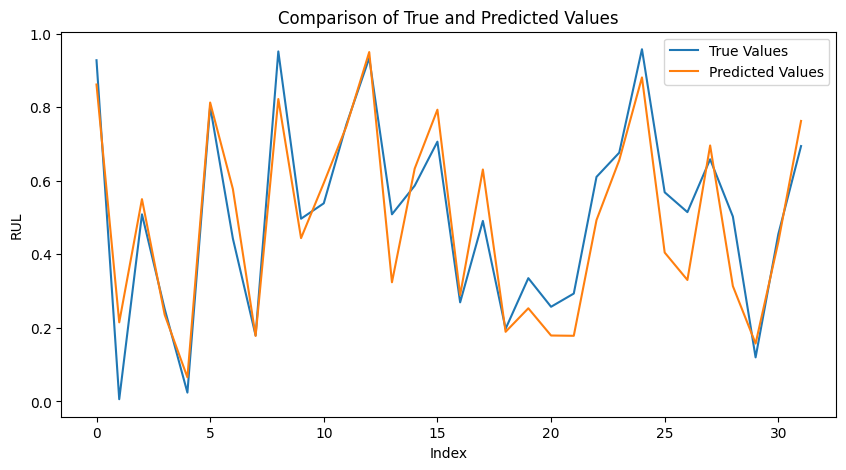

In [33]:
X_test = torch.tensor(X_RUL_test, dtype=torch.float32)
y_true = np.array(y_RUL_test).reshape(-1)

model.eval()
with torch.no_grad():
    y_pred = model(X_test).detach().cpu().numpy().reshape(-1)

mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mse)

print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)

plt.figure(figsize=(10, 5))

plt.plot(y_true, label='True Values')

plt.plot(y_pred, label='Predicted Values')

plt.title('Comparison of True and Predicted Values')
plt.xlabel('Index')
plt.ylabel('RUL')
plt.legend()
plt.show()

## مدل ساخته شده با دقت خوبی قادر به پیش بینی طول عمر مفید باتری است. کافی است مقادیر ویژگی ها به مدل داده شود تا طول عمر مفید را محاسبه کند.

In [44]:
# به عنوان مثال یک نمونه از داده های تست را جهت بررسی فراخوانی نموده و طول عمر مفید محاسبه می شود. 
sample_index = 8
X_sample = X_test[sample_index]  # shape: [time_steps,features]
if isinstance(X_sample, np.ndarray):
    X_sample = torch.tensor(X_sample, dtype=torch.float32)
    
X_sample = X_sample.unsqueeze(0).to(device) #shape: [1, time_steps, features]

model.eval()
with torch.no_grad():
    pred_rul = model(X_sample)

predicted_rul_scaled = pred_rul.cpu().numpy().reshape(-1, 1)
predicted_rul = scaler.inverse_transform(predicted_rul_scaled)

predicted_rul_scaled = pred_rul.item()

print('sample index:', sample_index)
print(f"Predicted RUL: {predicted_rul[0][0]:.2f}")
print(f"scaled RUL: {predicted_rul_scaled:.2f}")

sample index: 8
Predicted RUL: 137.37
scaled RUL: 0.82


برای نمونه 8 مقدار عمر مفید 137.37 نسبت به 168 می باشد. یعنی حدود 82 درصد